Car Price Prediction with ML (Rushi Mineshkumar Gandhi) 

In [28]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression, Lasso
from sklearn.ensemble import RandomForestRegressor
from sklearn import metrics
import joblib
import warnings
warnings.filterwarnings('ignore')

sns.set_style('whitegrid')

In [29]:
df = pd.read_csv("car data.csv")

In [30]:
df.head()

,Car_Name,Year,Selling_Price,Present_Price,Driven_kms,Fuel_Type,Selling_type,Transmission,Owner
0,ritz,2014,3.35,5.59,27000,Petrol,Dealer,Manual,0
1,sx4,2013,4.75,9.54,43000,Diesel,Dealer,Manual,0
2,ciaz,2017,7.25,9.85,6900,Petrol,Dealer,Manual,0
3,wagon r,2011,2.85,4.15,5200,Petrol,Dealer,Manual,0
4,swift,2014,4.60,6.87,42450,Diesel,Dealer,Manual,0


In [31]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 301 entries, 0 to 300
Data columns (total 9 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Car_Name       301 non-null    object 
 1   Year           301 non-null    int64  
 2   Selling_Price  301 non-null    float64
 3   Present_Price  301 non-null    float64
 4   Driven_kms     301 non-null    int64  
 5   Fuel_Type      301 non-null    object 
 6   Selling_type   301 non-null    object 
 7   Transmission   301 non-null    object 
 8   Owner          301 non-null    int64  
dtypes: float64(2), int64(3), object(4)
memory usage: 21.3+ KB


In [32]:
df.shape

(301, 9)

In [33]:
df.isnull().sum()

Car_Name         0
Year             0
Selling_Price    0
Present_Price    0
Driven_kms       0
Fuel_Type        0
Selling_type     0
Transmission     0
Owner            0
dtype: int64

In [34]:
df.describe()

,Year,Selling_Price,Present_Price,Driven_kms,Owner
count,301.000000,301.000000,301.000000,301.000000,301.000000
mean,2013.627907,4.661296,7.628472,36947.205980,0.043189
std,2.891554,5.082812,8.642584,38886.883882,0.247915
min,2003.000000,0.100000,0.320000,500.000000,0.000000
25%,2012.000000,0.900000,1.200000,15000.000000,0.000000
50%,2014.000000,3.600000,6.400000,32000.000000,0.000000
75%,2016.000000,6.000000,9.900000,48767.000000,0.000000
max,2018.000000,35.000000,92.600000,500000.000000,3.000000


In [35]:
print('\nfuel type:')
print(df['Fuel_Type'].value_counts())

print('\nseller type:')
print(df['Selling_type'].value_counts())

print('\nTransmission:')
print(df['Transmission'].value_counts())

print('\nOwner:')
print(df['Owner'].value_counts())


fuel type:
Fuel_Type
Petrol    239
Diesel     60
CNG         2
Name: count, dtype: int64

seller type:
Selling_type
Dealer        195
Individual    106
Name: count, dtype: int64

Transmission:
Transmission
Manual       261
Automatic     40
Name: count, dtype: int64

Owner:
Owner
0    290
1     10
3      1
Name: count, dtype: int64


Text(0.5, 1.0, 'Distribution of car selling price')

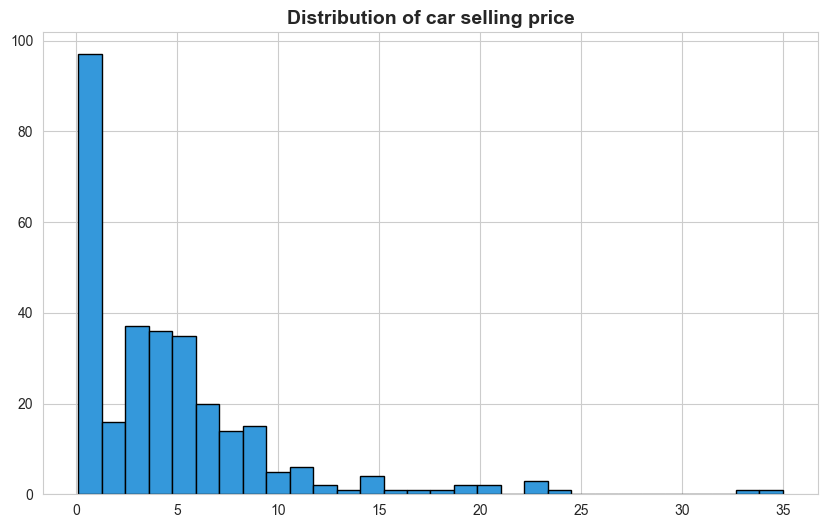

In [36]:
plt.figure(figsize=(10,6))
plt.hist(df['Selling_Price'], bins=30, color='#3498db', edgecolor='black')
plt.title('Distribution of car selling price', fontsize=14, fontweight='bold')

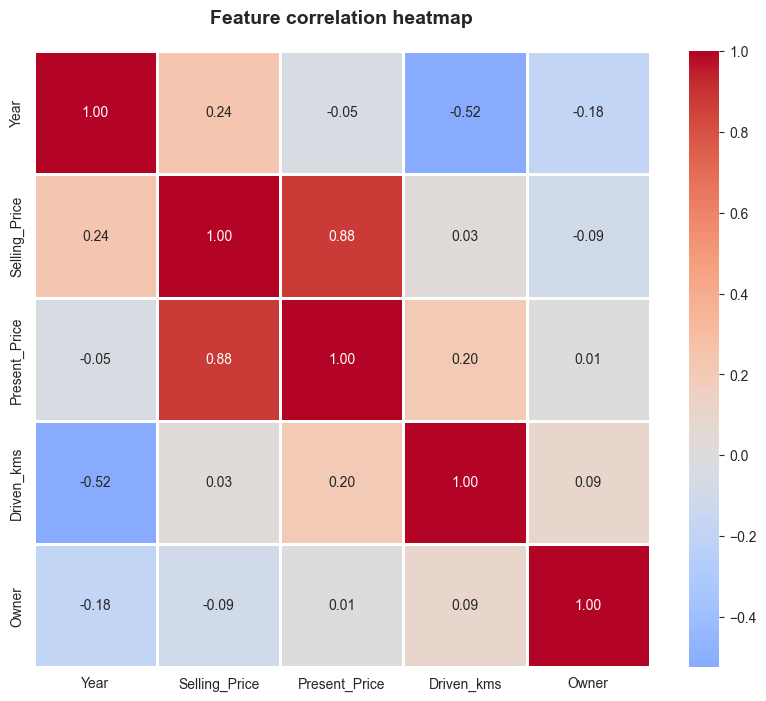

In [41]:
plt.figure(figsize=(10,8))
numeric_data = df.select_dtypes(include=[np.number])
correlation = numeric_data.corr()
sns.heatmap(correlation, annot=True, cmap='coolwarm', center=0, square=True, linewidths=1, fmt='.2f')
plt.title('Feature correlation heatmap', fontsize=14, fontweight='bold', pad=20)
plt.show()

Text(0, 0.5, 'selling price(Lakhs)')

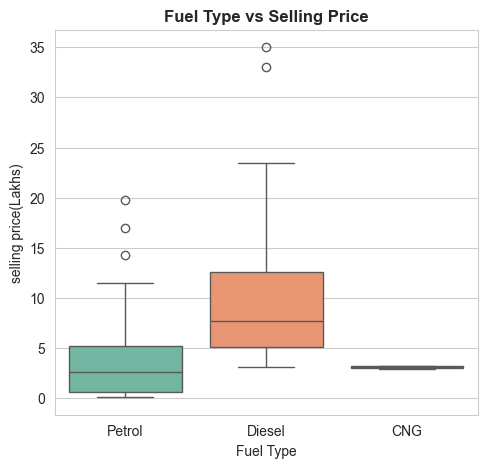

In [45]:
#fuel type vs selling price
plt.figure(figsize=(12,5))
plt.subplot(1,2,1)
sns.boxplot(x='Fuel_Type', y='Selling_Price', data=df, palette='Set2')
plt.title('Fuel Type vs Selling Price', fontweight='bold')
plt.xlabel('Fuel Type')
plt.ylabel('selling price(Lakhs)')

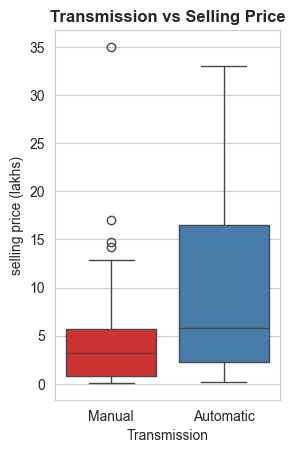

In [47]:
#Transmission vs selling price
plt.subplot(1,2,2)
sns.boxplot(x='Transmission', y='Selling_Price', data=df, palette='Set1')
plt.title('Transmission vs Selling Price', fontweight='bold')
plt.xlabel('Transmission')
plt.ylabel('selling price (lakhs)')
plt.show()

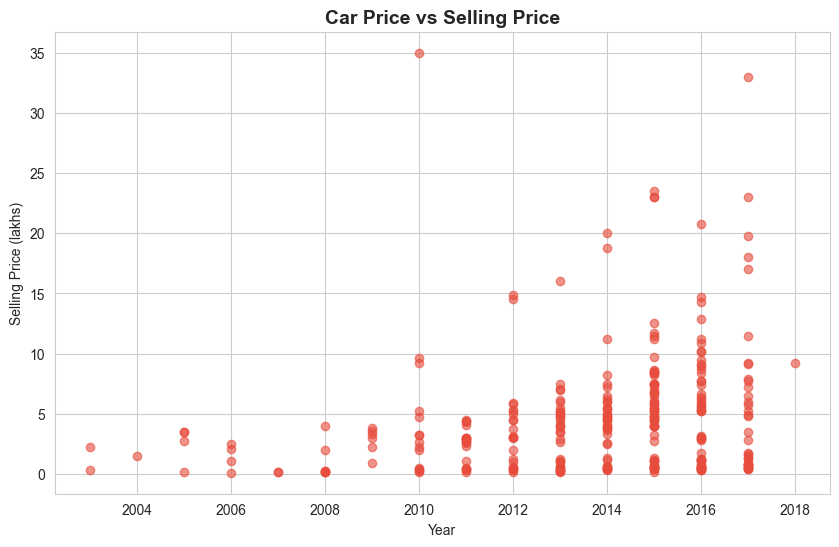

In [48]:
#year vs selling price
plt.figure(figsize=(10,6))
plt.scatter(df['Year'], df['Selling_Price'], alpha=0.6, c='#e74c3c')
plt.title('Car Price vs Selling Price', fontsize=14, fontweight='bold')
plt.xlabel('Year')
plt.ylabel('Selling Price (lakhs)')
plt.show()

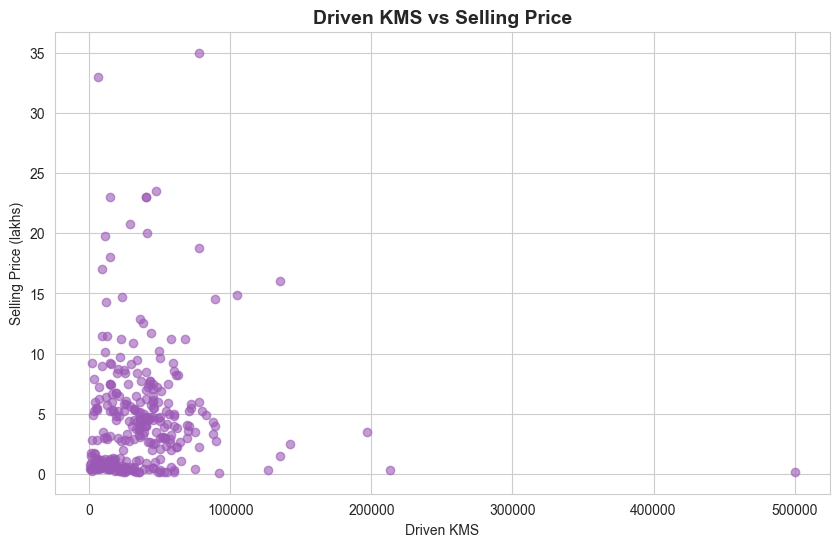

In [49]:
#driven kms vs selling price
plt.figure(figsize=(10,6))
plt.scatter(df['Driven_kms'], df['Selling_Price'], alpha=0.6, c='#9b59b6')
plt.title('Driven KMS vs Selling Price', fontsize=14, fontweight='bold')
plt.xlabel('Driven KMS')
plt.ylabel('Selling Price (lakhs)')
plt.show()

In [56]:
#Encoding 
df.replace({'Fuel_Type':{'Petrol':0, 'Diesel':1, 'CNG':2}}, inplace=True)
df.replace({'Selling_type':{'Dealer':0, 'Individual':1}}, inplace=True)
df.replace({'Transmission':{'Manual':0, 'Automatic':1}}, inplace=True)

print('Encoded Dataset')
df.head()

Encoded Dataset


,Car_Name,Year,Selling_Price,Present_Price,Driven_kms,Fuel_Type,Selling_type,Transmission,Owner
0,ritz,2014,3.35,5.59,27000,0,0,0,0
1,sx4,2013,4.75,9.54,43000,1,0,0,0
2,ciaz,2017,7.25,9.85,6900,0,0,0,0
3,wagon r,2011,2.85,4.15,5200,0,0,0,0
4,swift,2014,4.60,6.87,42450,1,0,0,0


In [57]:
X = df.drop(['Car_Name', 'Selling_Price'], axis=1)
X.head()

,Year,Present_Price,Driven_kms,Fuel_Type,Selling_type,Transmission,Owner
0,2014,5.59,27000,0,0,0,0
1,2013,9.54,43000,1,0,0,0
2,2017,9.85,6900,0,0,0,0
3,2011,4.15,5200,0,0,0,0
4,2014,6.87,42450,1,0,0,0


In [58]:
y = df['Selling_Price']
y.head()

0    3.35
1    4.75
2    7.25
3    2.85
4    4.60
Name: Selling_Price, dtype: float64

In [66]:
X_train,X_test,y_train,y_test = train_test_split(
    X,y, test_size=0.2, random_state=42)
print('training sample 80%:',x_train.shape[0])

training sample 80%: 240


In [67]:
print('testing sample 20%:',X_test.shape[0])

testing sample 20%: 61


In [69]:
#try model 1 LinearRegression

lin = LinearRegression()
lin.fit(X_train,y_train)
               

,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None
,positive,False


In [75]:
y_pred = lin.predict(X_train)
r2 = metrics.r2_score(y_train,y_pred)
mae = metrics.mean_absolute_error(y_train,y_pred)
rmse = np.sqrt(metrics.mean_squared_error(y_train,y_pred))

print('r2 score:',r2)
print('MAE:',mae)
print('RMSE:',rmse)

r2 score: 0.8836563703329269
MAE: 1.1794886257558863
RMSE: 1.7537910792060476


In [76]:
y_pred = lin.predict(X_test)
r2 = metrics.r2_score(y_test,y_pred)
mae = metrics.mean_absolute_error(y_test,y_pred)
rmse = np.sqrt(metrics.mean_squared_error(y_test,y_pred))

print('r2 score:',r2)
print('MAE:',mae)
print('RMSE:',rmse)

r2 score: 0.8466902419663409
MAE: 1.2219323621754232
RMSE: 1.8792498207980757


Text(0.5, 1.0, 'Linear Regression - Testing')

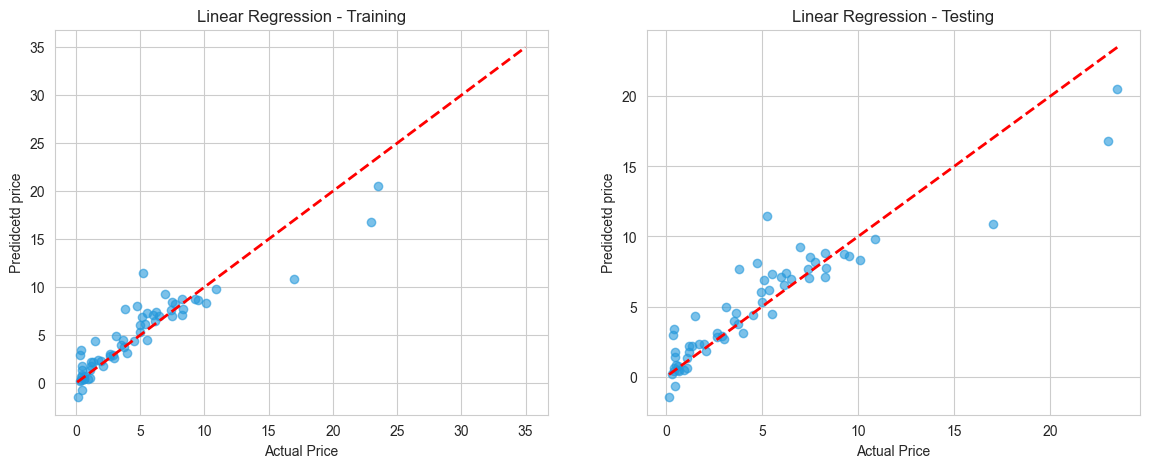

In [88]:
fig, axes = plt.subplots(1,2,figsize=(14,5))

axes[0].scatter(y_test, y_pred, alpha=0.6, color='#2498db')
axes[0].plot([y_train.min(), y_train.max()], [y_train.min(), y_train.max()], 'r--', lw=2)
axes[0].set_xlabel('Actual Price')
axes[0].set_ylabel('Predidcetd price')
axes[0].set_title("Linear Regression - Training")

axes[1].scatter(y_test, y_pred, alpha=0.6, color='#2498db')
axes[1].plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', lw=2)
axes[1].set_xlabel('Actual Price')
axes[1].set_ylabel('Predidcetd price')
axes[1].set_title("Linear Regression - Testing")

In [90]:
#model 2 lasso regression

lasso = Lasso(alpha=0.1)
lasso.fit(X_train, y_train)

,alpha,0.1
,fit_intercept,True
,precompute,False
,copy_X,True
,max_iter,1000
,tol,0.0001
,warm_start,False
,positive,False
,random_state,None
,selection,'cyclic'


In [93]:
y_pred_lasso = lasso.predict(X_train)
r2 = metrics.r2_score(y_train, y_pred_lasso)
mae = metrics.mean_absolute_error(y_train, y_pred_lasso)
rmse = np.sqrt(metrics.mean_squared_error(y_train, y_pred_lasso))

print('r2:',r2)
print('mae:',mae)
print('rmse:',rmse)

r2: 0.8722819736901272
mae: 1.1613148644025044
rmse: 1.837522440672096


In [94]:
y_pred_lasso = lasso.predict(X_test)
r2 = metrics.r2_score(y_test, y_pred_lasso)
mae = metrics.mean_absolute_error(y_test, y_pred_lasso)
rmse = np.sqrt(metrics.mean_squared_error(y_test, y_pred_lasso))

print('r2:',r2)
print('mae:',mae)
print('rmse:',rmse)

r2: 0.8446762267416501
mae: 1.2176848470592705
rmse: 1.8915533053295426


Text(0.5, 1.0, 'Lasso Regression - Testing')

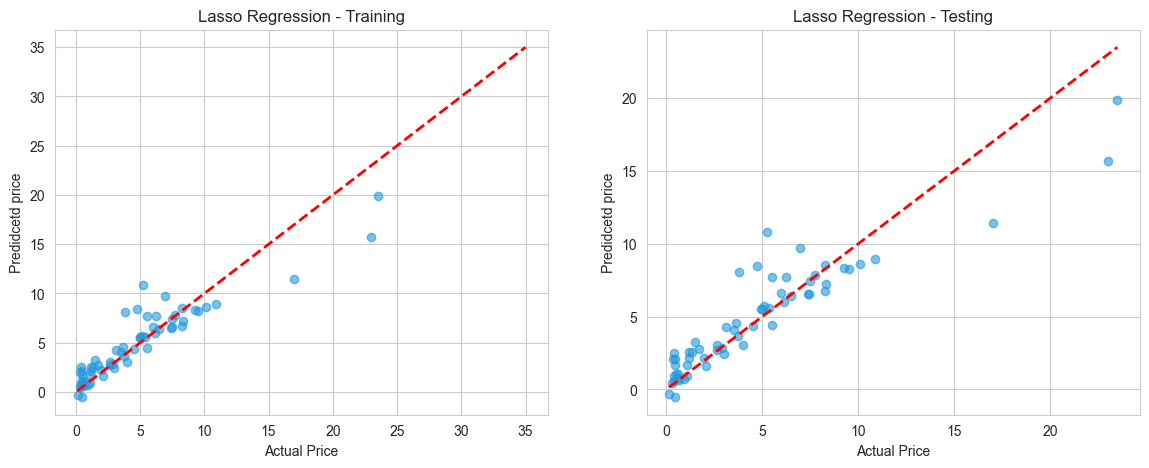

In [97]:
fig, axes = plt.subplots(1,2,figsize=(14,5))

axes[0].scatter(y_test, y_pred_lasso, alpha=0.6, color='#2498db')
axes[0].plot([y_train.min(), y_train.max()], [y_train.min(), y_train.max()], 'r--', lw=2)
axes[0].set_xlabel('Actual Price')
axes[0].set_ylabel('Predidcetd price')
axes[0].set_title("Lasso Regression - Training")

axes[1].scatter(y_test, y_pred_lasso, alpha=0.6, color='#2498db')
axes[1].plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', lw=2)
axes[1].set_xlabel('Actual Price')
axes[1].set_ylabel('Predidcetd price')
axes[1].set_title("Lasso Regression - Testing")

In [98]:
#model 3 Random forest
rf = RandomForestRegressor(n_estimators=100, random_state=2)
rf.fit(X_train, y_train)

,n_estimators,100
,criterion,'squared_error'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,1.0
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


In [99]:
y_pred_rf = rf.predict(X_train)
r2 = metrics.r2_score(y_train, y_pred_rf)
mae = metrics.mean_absolute_error(y_train, y_pred_rf)
rmse = np.sqrt(metrics.mean_squared_error(y_train, y_pred_rf))

print('r2:',r2)
print('mae:',mae)
print('rmse:',rmse)

r2: 0.9839596874303659
mae: 0.2642824999999997
rmse: 0.651197861636538


In [100]:
y_pred_rf = rf.predict(X_test)
r2 = metrics.r2_score(y_test, y_pred_rf)
mae = metrics.mean_absolute_error(y_test, y_pred_rf)
rmse = np.sqrt(metrics.mean_squared_error(y_test, y_pred_rf))

print('r2:',r2)
print('mae:',mae)
print('rmse:',rmse)

r2: 0.9653096836523327
mae: 0.5700377049180333
rmse: 0.8939304862584649


In [109]:
feature_importance = pd.DataFrame({
    'Feature': X.columns,
    'Importance': rf.feature_importances_
}).sort_values('Importance', ascending=False)

print(feature_importance)

         Feature  Importance
1  Present_Price    0.890274
0           Year    0.060242
2     Driven_kms    0.033780
5   Transmission    0.006827
3      Fuel_Type    0.004095
4   Selling_type    0.003458
6          Owner    0.001324


Text(0.5, 1.0, 'Random Forest - Testing')

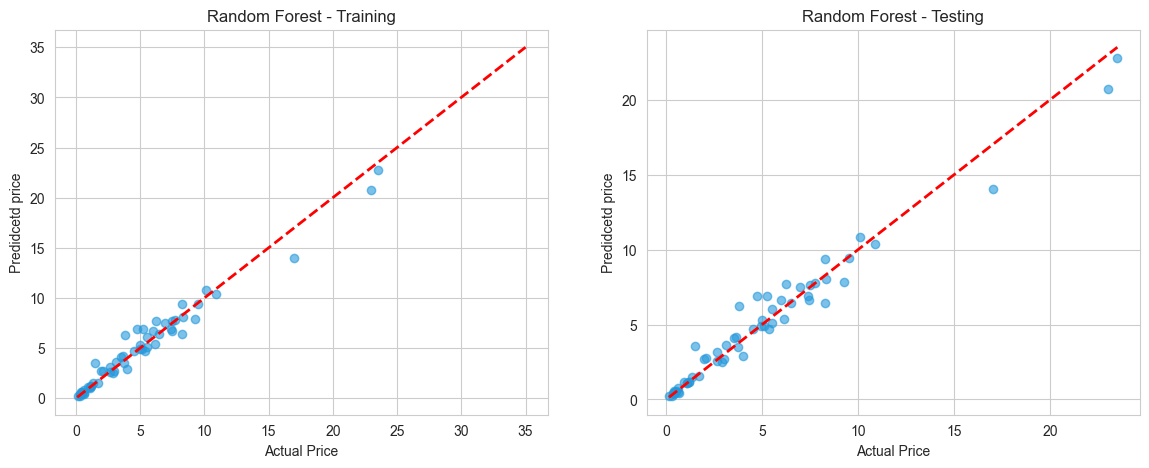

In [110]:
fig, axes = plt.subplots(1, 2, figsize=(14,5))

axes[0].scatter(y_test, y_pred_rf, alpha=0.6, color='#2498db')
axes[0].plot([y_train.min(), y_train.max()], [y_train.min(), y_train.max()], 'r--', lw=2)
axes[0].set_xlabel('Actual Price')
axes[0].set_ylabel('Predidcetd price')
axes[0].set_title("Random Forest - Training")

axes[1].scatter(y_test, y_pred_rf, alpha=0.6, color='#2498db')
axes[1].plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', lw=2)
axes[1].set_xlabel('Actual Price')
axes[1].set_ylabel('Predidcetd price')
axes[1].set_title("Random Forest - Testing")

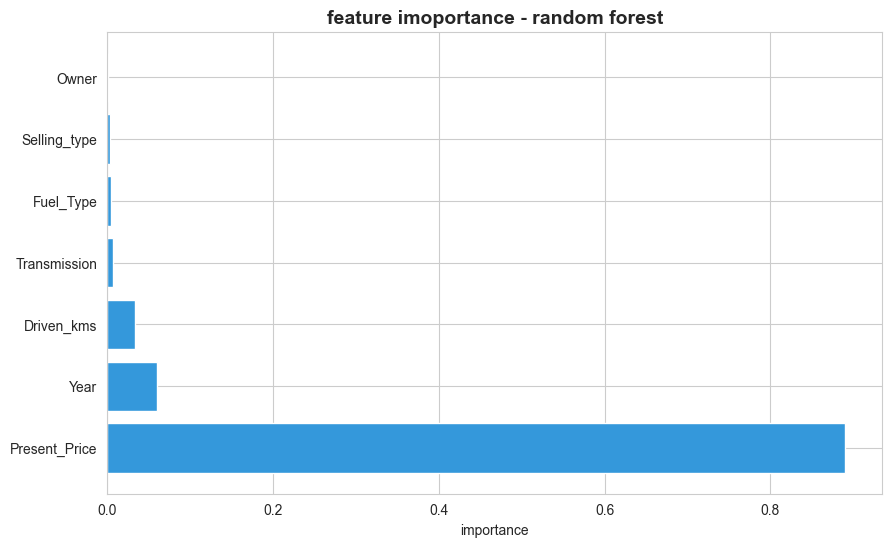

In [111]:
plt.figure(figsize=(10,6))
plt.barh(feature_importance['Feature'], feature_importance['Importance'], color='#3498db')
plt.xlabel('importance')
plt.title('feature imoportance - random forest', fontsize=14, fontweight='bold')
plt.show()

In [112]:
#Save best model

joblib.dump(rf, 'Car_prediction_model.pkl')

['Car_prediction_model.pkl']

In [120]:
input_data = pd.DataFrame({
    'Year': [2014],
    'Present_Price': [7],
    'Driven_kms': [160000],
    'Fuel_Type': [1],
    'Selling_type': [1],
    'Transmission': [0],
    'Owner': [1]
})

prediction = rf.predict(input_data)[0]
print(prediction)

4.529499999999996
